<a href="https://colab.research.google.com/github/akhunzakp/PCVK-2025/blob/main/Case%20Method.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Bagian A – Observasi & Eksperimen**

Gunakan 3 citra wajah (misalnya face1.jpg, face2.jpg, face3.jpg) dengan variasi kondisi cahaya.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install pillow pillow-heif


**1. Tampilkan histogram tiap citra dan analisis distribusi intensitasnya.**




✅ Semua gambar berhasil dibaca!


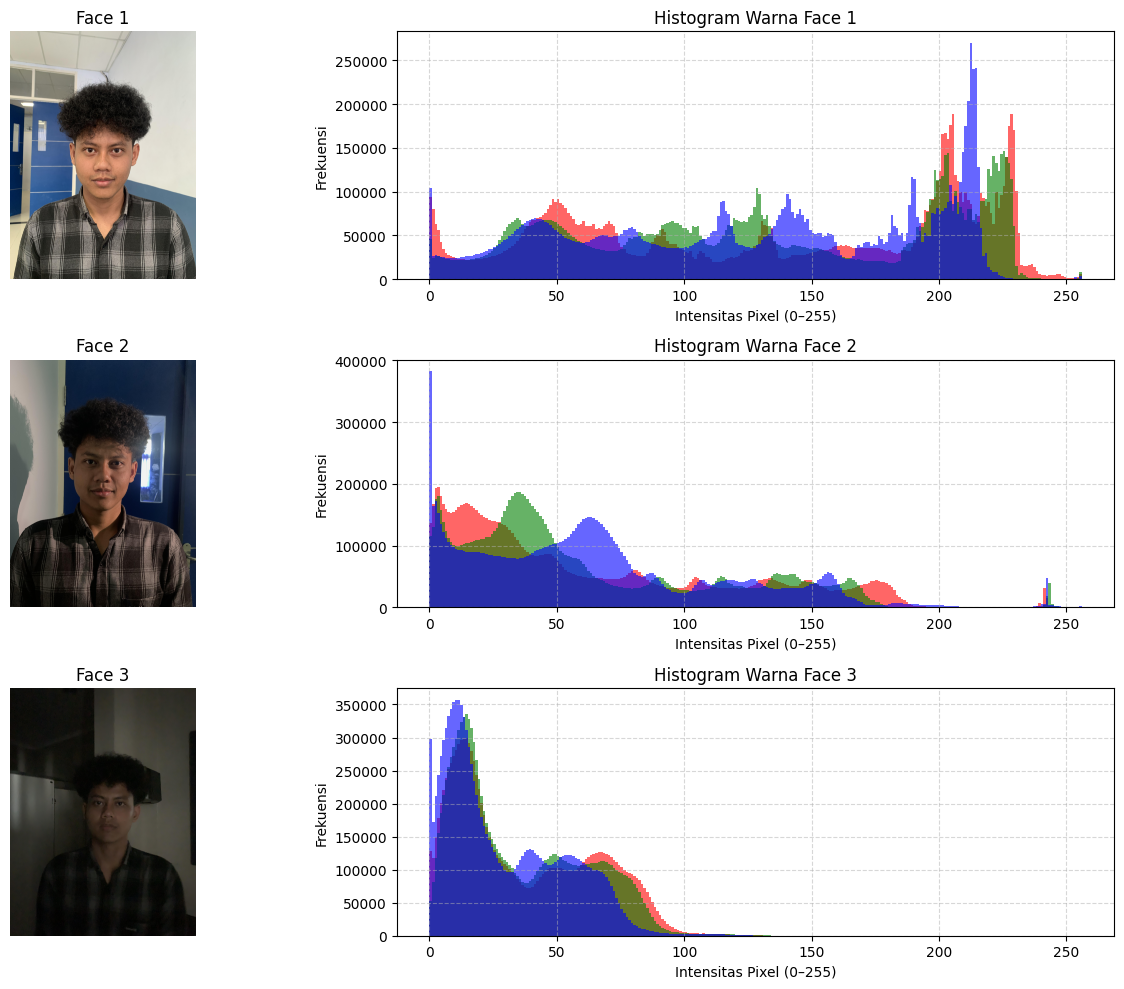

In [ ]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

# ====== Path gambar yang BENAR (hasil konversi) ======
path1 = '/content/drive/MyDrive/PCVK/kaconkface/face1.jpg'
path2 = '/content/drive/MyDrive/PCVK/kaconkface/face2.jpg'
path3 = '/content/drive/MyDrive/PCVK/kaconkface/face3.jpg'

# ====== Baca gambar dalam mode warna (BGR) ======
face1 = cv2.imread(path1)
face2 = cv2.imread(path2)
face3 = cv2.imread(path3)

# ====== Pastikan gambar berhasil dibaca ======
if face1 is None or face2 is None or face3 is None:
    print("⚠️ Gagal dibaca! Cek kembali nama file dan path!")
else:
    print("✅ Semua gambar berhasil dibaca!")

    # ====== Konversi BGR ke RGB untuk ditampilkan dengan benar ======
    faces = [
        cv2.cvtColor(face1, cv2.COLOR_BGR2RGB),
        cv2.cvtColor(face2, cv2.COLOR_BGR2RGB),
        cv2.cvtColor(face3, cv2.COLOR_BGR2RGB)
    ]
    titles = ['Face 1', 'Face 2', 'Face 3']

    plt.figure(figsize=(14, 10))

    for i, (img, title) in enumerate(zip(faces, titles)):
        # ====== Tampilkan gambar berwarna ======
        plt.subplot(3, 2, 2*i + 1)
        plt.imshow(img)
        plt.title(title)
        plt.axis('off')

        # ====== Tampilkan histogram RGB ======
        plt.subplot(3, 2, 2*i + 2)
        colors = ('r', 'g', 'b')
        for j, color in enumerate(colors):
            plt.hist(img[:, :, j].ravel(), bins=256, range=[0, 256], color=color, alpha=0.6)
        plt.title(f'Histogram Warna {title}')
        plt.xlabel('Intensitas Pixel (0–255)')
        plt.ylabel('Frekuensi')
        plt.grid(True, linestyle='--', alpha=0.5)

    plt.tight_layout()
    plt.show()


✅ Semua gambar berhasil dibaca!


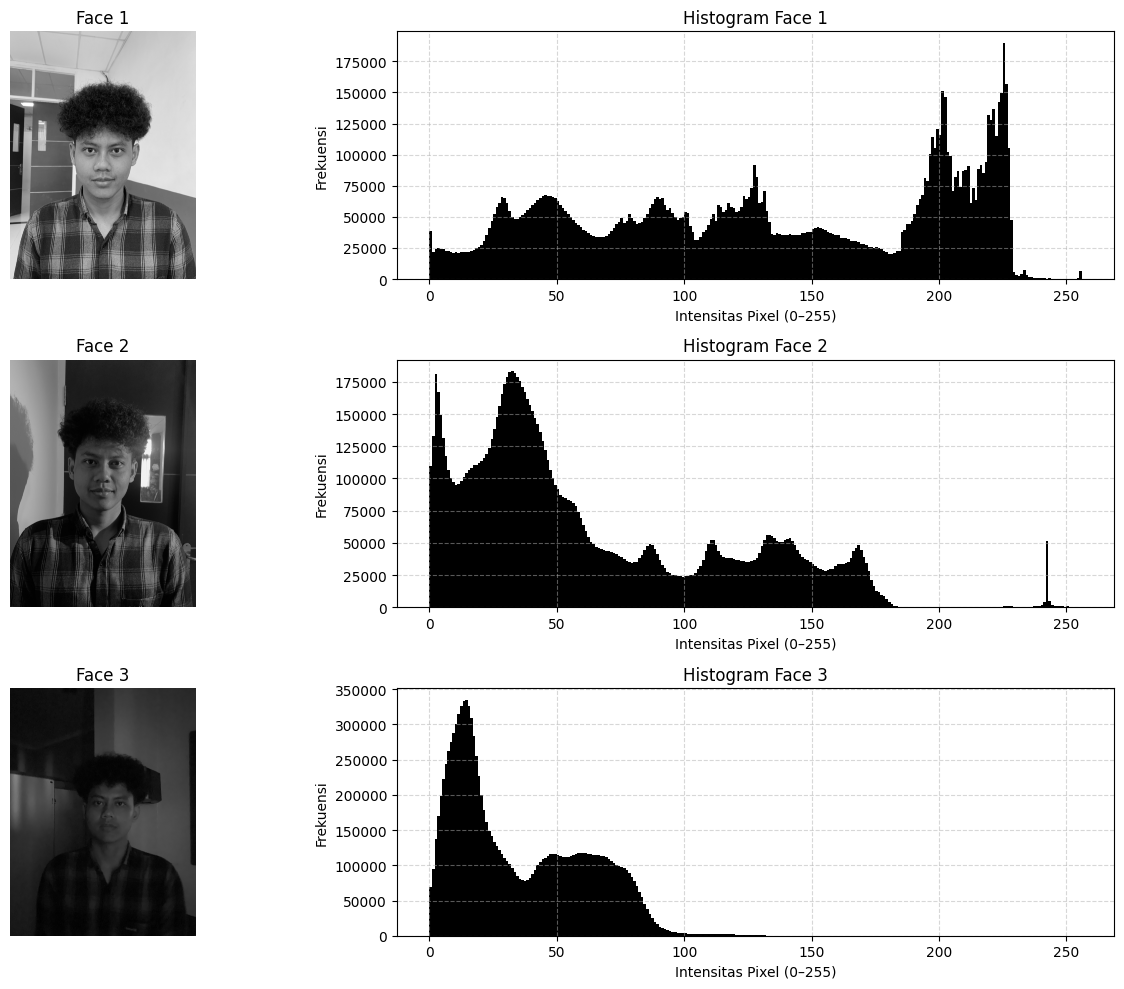

In [ ]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

# ====== Path gambar yang BENAR (hasil konversi) ======
path1 = '/content/drive/MyDrive/PCVK/kaconkface/face1.jpg'
path2 = '/content/drive/MyDrive/PCVK/kaconkface/face2.jpg'
path3 = '/content/drive/MyDrive/PCVK/kaconkface/face3.jpg'

# ====== Baca gambar dalam mode grayscale ======
face1 = cv2.imread(path1, cv2.IMREAD_GRAYSCALE)
face2 = cv2.imread(path2, cv2.IMREAD_GRAYSCALE)
face3 = cv2.imread(path3, cv2.IMREAD_GRAYSCALE)

# ====== Pastikan gambar berhasil dibaca ======
if face1 is None or face2 is None or face3 is None:
    print("⚠️ Gagal dibaca! Cek kembali nama file dan path!")
else:
    print("✅ Semua gambar berhasil dibaca!")

    # ====== Tampilkan gambar dan histogram ======
    faces = [face1, face2, face3]
    titles = ['Face 1', 'Face 2', 'Face 3']

    plt.figure(figsize=(14, 10))
    for i, (img, title) in enumerate(zip(faces, titles)):
        # Gambar asli
        plt.subplot(3, 2, 2*i + 1)
        plt.imshow(img, cmap='gray')
        plt.title(title)
        plt.axis('off')

        # Histogram
        plt.subplot(3, 2, 2*i + 2)
        plt.hist(img.ravel(), bins=256, range=[0, 256], color='black')
        plt.title(f'Histogram {title}')
        plt.xlabel('Intensitas Pixel (0–255)')
        plt.ylabel('Frekuensi')
        plt.grid(True, linestyle='--', alpha=0.5)

    plt.tight_layout()
    plt.show()


**2. Terapkan transformasi brightness dan contrast (linear/log brightness).**


*   Tentukan nilai b (brightness) dan a (contrast) yang sesuai agar wajah tampak
natural.



✅ Semua gambar berhasil dibaca!


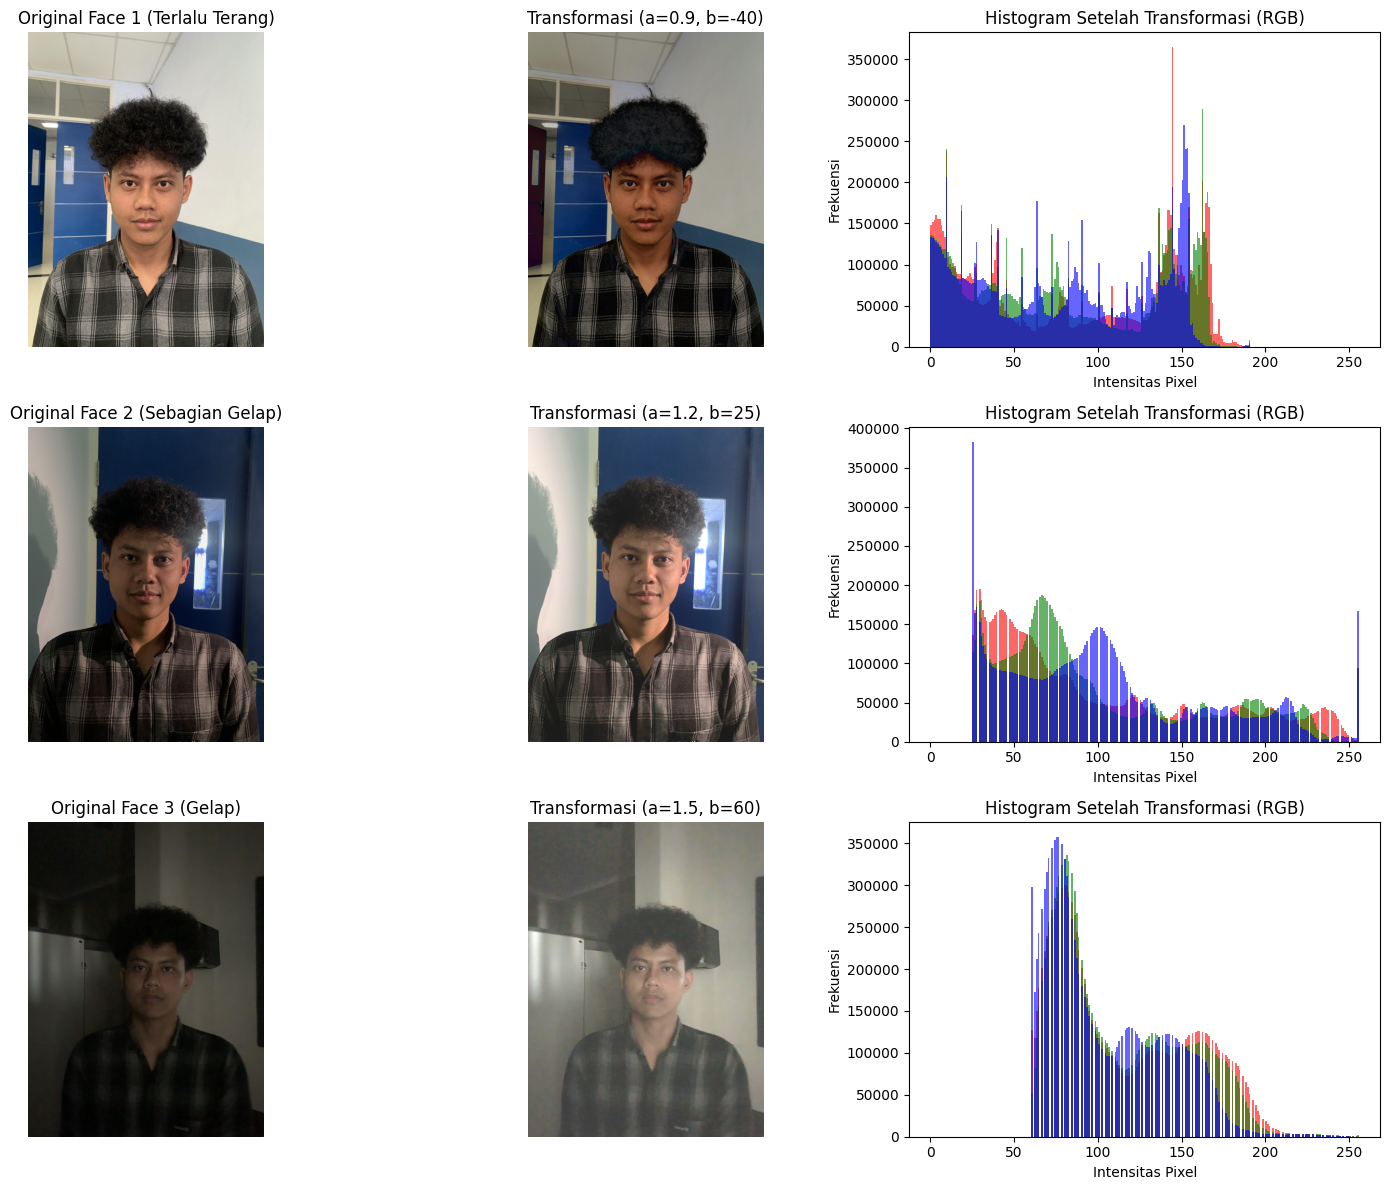

In [ ]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

# ====== Path gambar (hasil konversi dari HEIF) ======
path1 = '/content/drive/MyDrive/PCVK/kaconkface/face1.jpg'
path2 = '/content/drive/MyDrive/PCVK/kaconkface/face2.jpg'
path3 = '/content/drive/MyDrive/PCVK/kaconkface/face3.jpg'

# ====== Baca gambar dalam mode warna (BGR) ======
face1 = cv2.imread(path1)
face2 = cv2.imread(path2)
face3 = cv2.imread(path3)

# ====== Pastikan semua gambar terbaca ======
if face1 is None or face2 is None or face3 is None:
    print("⚠️ Gagal membaca gambar! Cek path atau ekstensi file!")
else:
    print("✅ Semua gambar berhasil dibaca!")

    # ====== Penyesuaian brightness & contrast (a = kontras, b = kecerahan) ======
    params = [
        (0.9, -40),  # Face1 terang → kurangi brightness
        (1.2, 25),   # Face2 sebagian gelap → tambah brightness
        (1.5, 60)    # Face3 gelap → tambah kontras & brightness
    ]

    faces = [face1, face2, face3]
    titles = ['Face 1 (Terlalu Terang)', 'Face 2 (Sebagian Gelap)', 'Face 3 (Gelap)']

    plt.figure(figsize=(15, 12))

    for i, (img_bgr, (a, b), title) in enumerate(zip(faces, params, titles)):
        # Konversi BGR → RGB untuk visualisasi
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

        # ====== Penyesuaian brightness & contrast ======
        adjusted = cv2.convertScaleAbs(img_rgb, alpha=a, beta=b)

        # ====== Plot hasil sebelum & sesudah ======
        plt.subplot(3, 3, 3*i + 1)
        plt.imshow(img_rgb)
        plt.title(f'Original {title}')
        plt.axis('off')

        plt.subplot(3, 3, 3*i + 2)
        plt.imshow(adjusted)
        plt.title(f'Transformasi (a={a}, b={b})')
        plt.axis('off')

        # ====== Histogram RGB setelah transformasi ======
        plt.subplot(3, 3, 3*i + 3)
        colors = ('r', 'g', 'b')
        for j, color in enumerate(colors):
            plt.hist(adjusted[:, :, j].ravel(), bins=256, range=[0, 256], color=color, alpha=0.6)
        plt.title('Histogram Setelah Transformasi (RGB)')
        plt.xlabel('Intensitas Pixel')
        plt.ylabel('Frekuensi')

    plt.tight_layout()
    plt.show()


✅ Semua gambar berhasil dibaca!


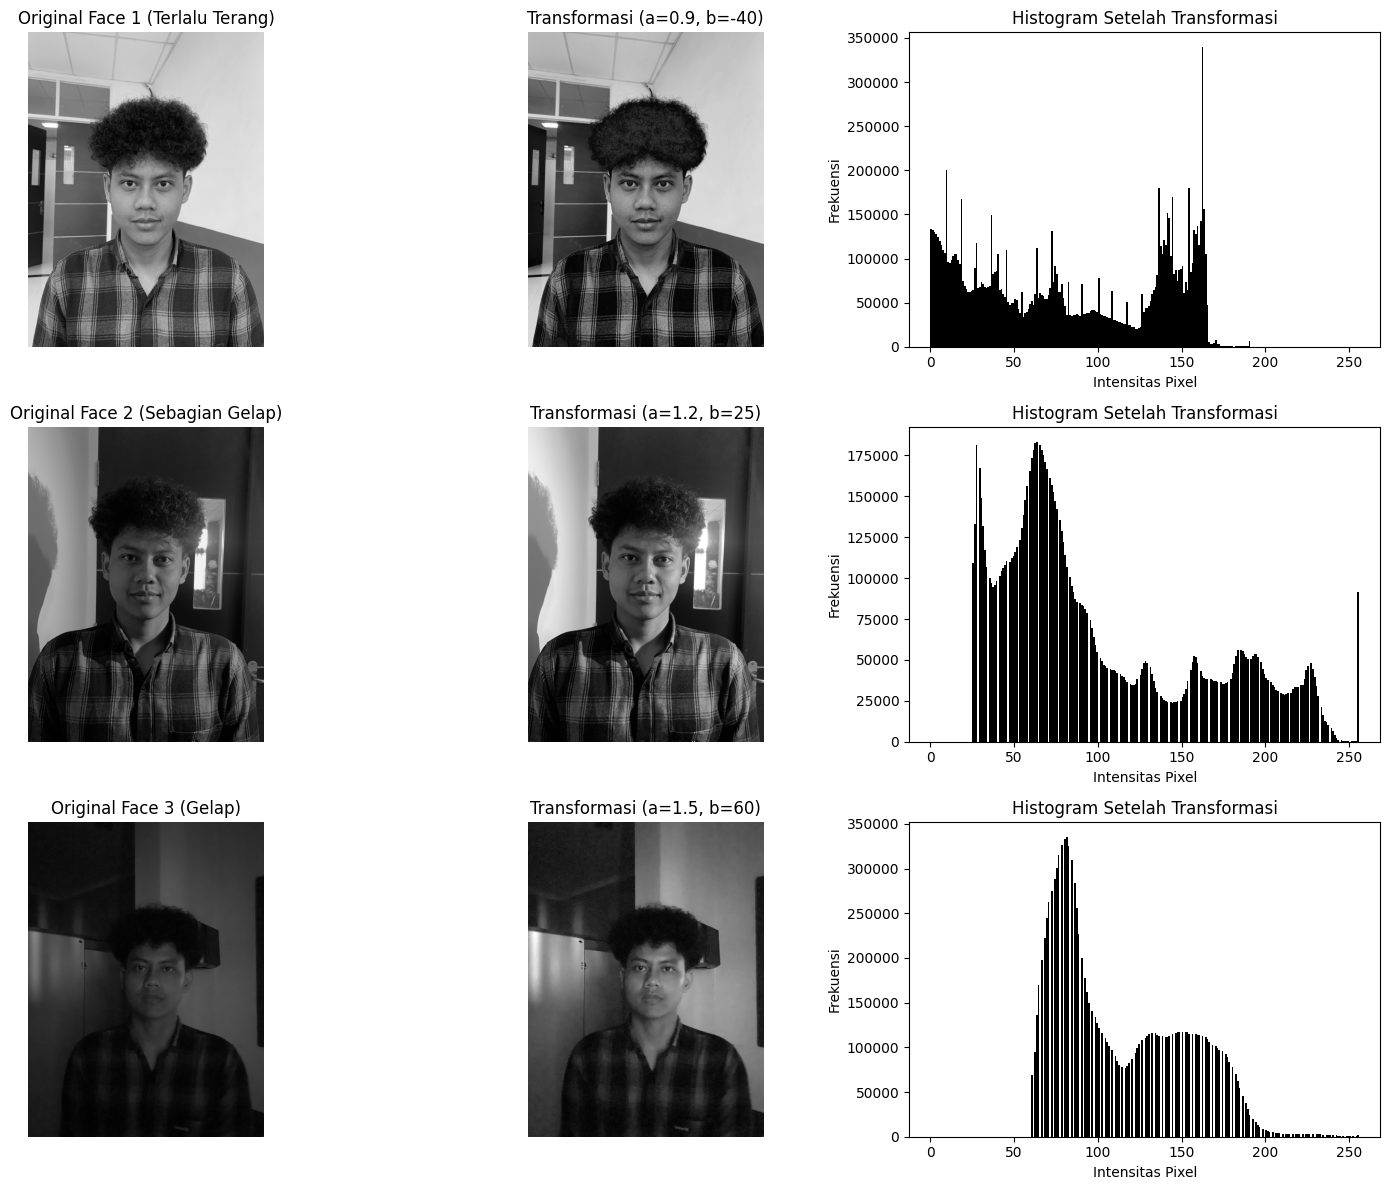

In [ ]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

# ====== Path gambar (hasil konversi dari HEIF) ======
path1 = '/content/drive/MyDrive/PCVK/kaconkface/face1.jpg'
path2 = '/content/drive/MyDrive/PCVK/kaconkface/face2.jpg'
path3 = '/content/drive/MyDrive/PCVK/kaconkface/face3.jpg'

# ====== Baca gambar grayscale ======
face1 = cv2.imread(path1, cv2.IMREAD_GRAYSCALE)
face2 = cv2.imread(path2, cv2.IMREAD_GRAYSCALE)
face3 = cv2.imread(path3, cv2.IMREAD_GRAYSCALE)

# ====== Pastikan semua gambar terbaca ======
if face1 is None or face2 is None or face3 is None:
    print("⚠️ Gagal membaca gambar! Cek path atau ekstensi file!")
else:
    print("✅ Semua gambar berhasil dibaca!")

    # ====== Penyesuaian brightness & contrast (a = kontras, b = kecerahan) ======
    # Face1: terlalu terang → kurangi brightness & sedikit turunkan kontras
    # Face2: sebagian gelap → tambahkan brightness & sedikit tingkatkan kontras
    # Face3: gelap → tambahkan brightness & kontras tinggi
    params = [
        (0.9, -40),  # Face1 terang
        (1.2, 25),   # Face2 sebagian gelap
        (1.5, 60)    # Face3 gelap
    ]

    faces = [face1, face2, face3]
    titles = ['Face 1 (Terlalu Terang)', 'Face 2 (Sebagian Gelap)', 'Face 3 (Gelap)']

    plt.figure(figsize=(15, 12))

    for i, (img, (a, b), title) in enumerate(zip(faces, params, titles)):
        # Terapkan transformasi brightness & contrast
        adjusted = cv2.convertScaleAbs(img, alpha=a, beta=b)

        # Tampilkan hasil perbandingan
        plt.subplot(3, 3, 3*i + 1)
        plt.imshow(img, cmap='gray')
        plt.title(f'Original {title}')
        plt.axis('off')

        plt.subplot(3, 3, 3*i + 2)
        plt.imshow(adjusted, cmap='gray')
        plt.title(f'Transformasi (a={a}, b={b})')
        plt.axis('off')

        # Histogram hasil transformasi
        plt.subplot(3, 3, 3*i + 3)
        plt.hist(adjusted.ravel(), bins=256, range=[0, 256], color='black')
        plt.title('Histogram Setelah Transformasi')
        plt.xlabel('Intensitas Pixel')
        plt.ylabel('Frekuensi')

    plt.tight_layout()
    plt.show()


**3. Lakukan histogram equalization untuk memperbaiki sebaran kontras.**

*  Bandingkan hasil visual dan histogram sebelum–sesudah.

✅ Gambar berhasil dibaca untuk Histogram Equalization (warna)!


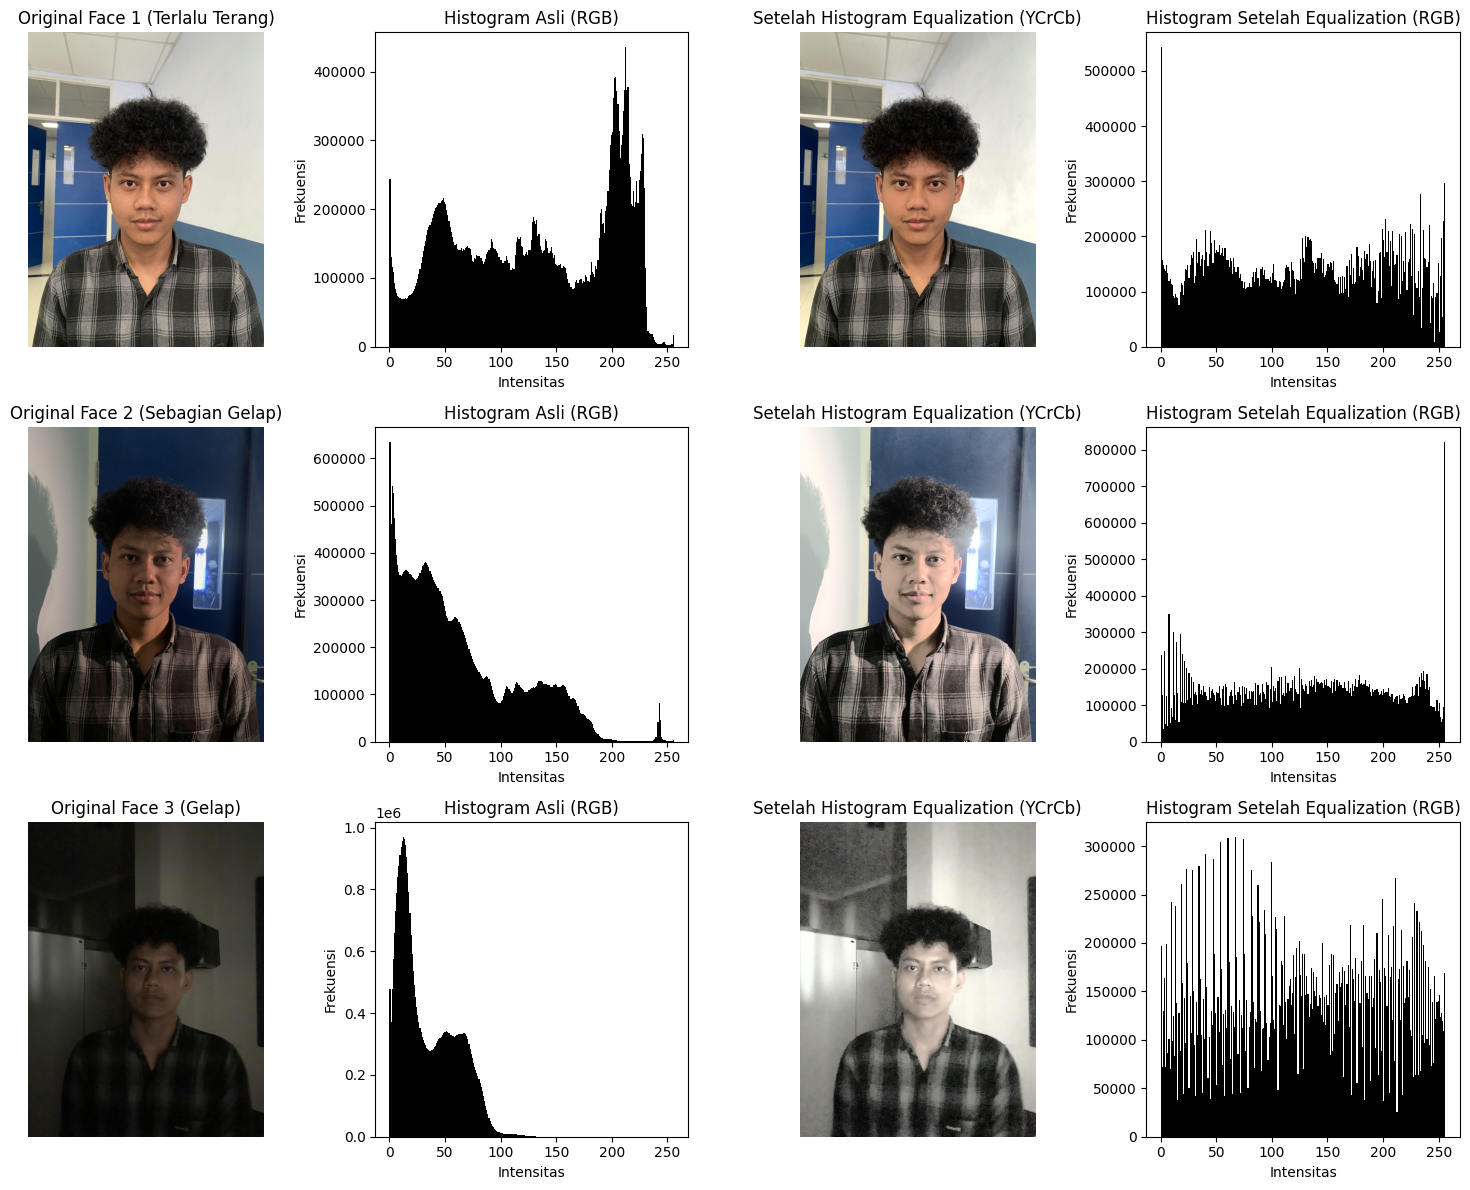

In [ ]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

# ====== Path gambar ======
path1 = '/content/drive/MyDrive/PCVK/kaconkface/face1.jpg'
path2 = '/content/drive/MyDrive/PCVK/kaconkface/face2.jpg'
path3 = '/content/drive/MyDrive/PCVK/kaconkface/face3.jpg'

# ====== Baca gambar dalam mode warna (BGR) ======
face1 = cv2.imread(path1)
face2 = cv2.imread(path2)
face3 = cv2.imread(path3)

if face1 is None or face2 is None or face3 is None:
    print("⚠️ Gagal membaca gambar! Cek path file.")
else:
    print("✅ Gambar berhasil dibaca untuk Histogram Equalization (warna)!")

    faces = [face1, face2, face3]
    titles = ['Face 1 (Terlalu Terang)', 'Face 2 (Sebagian Gelap)', 'Face 3 (Gelap)']

    plt.figure(figsize=(15, 12))

    for i, (img_bgr, title) in enumerate(zip(faces, titles)):
        # Konversi BGR -> YCrCb (Y = luminance)
        ycrcb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2YCrCb)
        y, Cr, Cb = cv2.split(ycrcb)

        # ====== Histogram Equalization pada channel Y saja ======
        y_eq = cv2.equalizeHist(y)
        ycrcb_eq = cv2.merge((y_eq, Cr, Cb))

        # Kembali ke format RGB untuk ditampilkan
        equalized_rgb = cv2.cvtColor(ycrcb_eq, cv2.COLOR_YCrCb2RGB)
        original_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

        # ====== Plot hasil sebelum & sesudah ======
        plt.subplot(3, 4, 4*i + 1)
        plt.imshow(original_rgb)
        plt.title(f'Original {title}')
        plt.axis('off')

        plt.subplot(3, 4, 4*i + 2)
        plt.hist(original_rgb.ravel(), bins=256, range=[0, 256], color='black')
        plt.title('Histogram Asli (RGB)')
        plt.xlabel('Intensitas')
        plt.ylabel('Frekuensi')

        plt.subplot(3, 4, 4*i + 3)
        plt.imshow(equalized_rgb)
        plt.title('Setelah Histogram Equalization (YCrCb)')
        plt.axis('off')

        plt.subplot(3, 4, 4*i + 4)
        plt.hist(equalized_rgb.ravel(), bins=256, range=[0, 256], color='black')
        plt.title('Histogram Setelah Equalization (RGB)')
        plt.xlabel('Intensitas')
        plt.ylabel('Frekuensi')

    plt.tight_layout()
    plt.show()


✅ Gambar berhasil dibaca untuk Histogram Equalization!


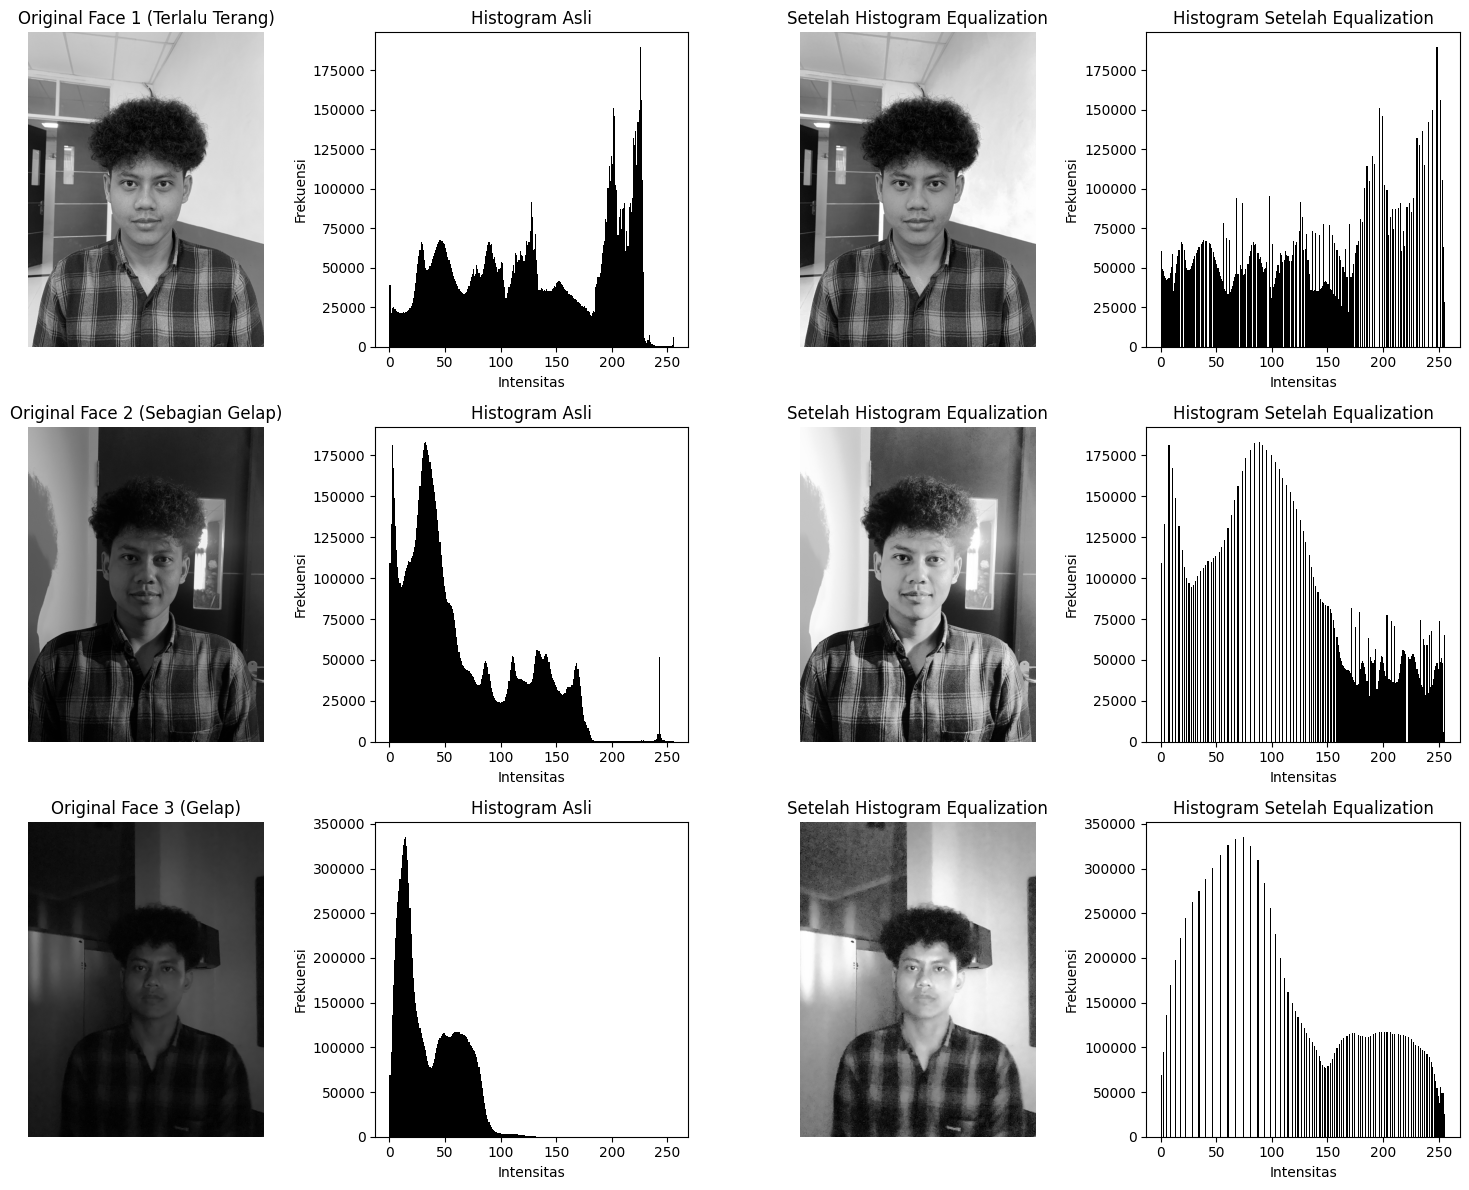

In [ ]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

# ====== Path gambar ======
path1 = '/content/drive/MyDrive/PCVK/kaconkface/face1.jpg'
path2 = '/content/drive/MyDrive/PCVK/kaconkface/face2.jpg'
path3 = '/content/drive/MyDrive/PCVK/kaconkface/face3.jpg'

# ====== Baca gambar dalam mode grayscale ======
face1 = cv2.imread(path1, cv2.IMREAD_GRAYSCALE)
face2 = cv2.imread(path2, cv2.IMREAD_GRAYSCALE)
face3 = cv2.imread(path3, cv2.IMREAD_GRAYSCALE)

if face1 is None or face2 is None or face3 is None:
    print("⚠️ Gagal membaca gambar! Cek path file.")
else:
    print("✅ Gambar berhasil dibaca untuk Histogram Equalization!")

    faces = [face1, face2, face3]
    titles = ['Face 1 (Terlalu Terang)', 'Face 2 (Sebagian Gelap)', 'Face 3 (Gelap)']

    plt.figure(figsize=(15, 12))

    for i, (img, title) in enumerate(zip(faces, titles)):
        # ====== Histogram Equalization ======
        equalized = cv2.equalizeHist(img)

        # ====== Plot hasil sebelum & sesudah ======
        plt.subplot(3, 4, 4*i + 1)
        plt.imshow(img, cmap='gray')
        plt.title(f'Original {title}')
        plt.axis('off')

        plt.subplot(3, 4, 4*i + 2)
        plt.hist(img.ravel(), bins=256, range=[0, 256], color='black')
        plt.title('Histogram Asli')
        plt.xlabel('Intensitas')
        plt.ylabel('Frekuensi')

        plt.subplot(3, 4, 4*i + 3)
        plt.imshow(equalized, cmap='gray')
        plt.title('Setelah Histogram Equalization')
        plt.axis('off')

        plt.subplot(3, 4, 4*i + 4)
        plt.hist(equalized.ravel(), bins=256, range=[0, 256], color='black')
        plt.title('Histogram Setelah Equalization')
        plt.xlabel('Intensitas')
        plt.ylabel('Frekuensi')

    plt.tight_layout()
    plt.show()


**4. Terapkan filter spasial:**

*  Low-pass filter untuk menghaluskan noise kulit wajah.
*  High-pass atau Laplacian filter untuk menajamkan tepi mata dan bibir.

✅ Gambar berhasil dibaca dalam format warna!


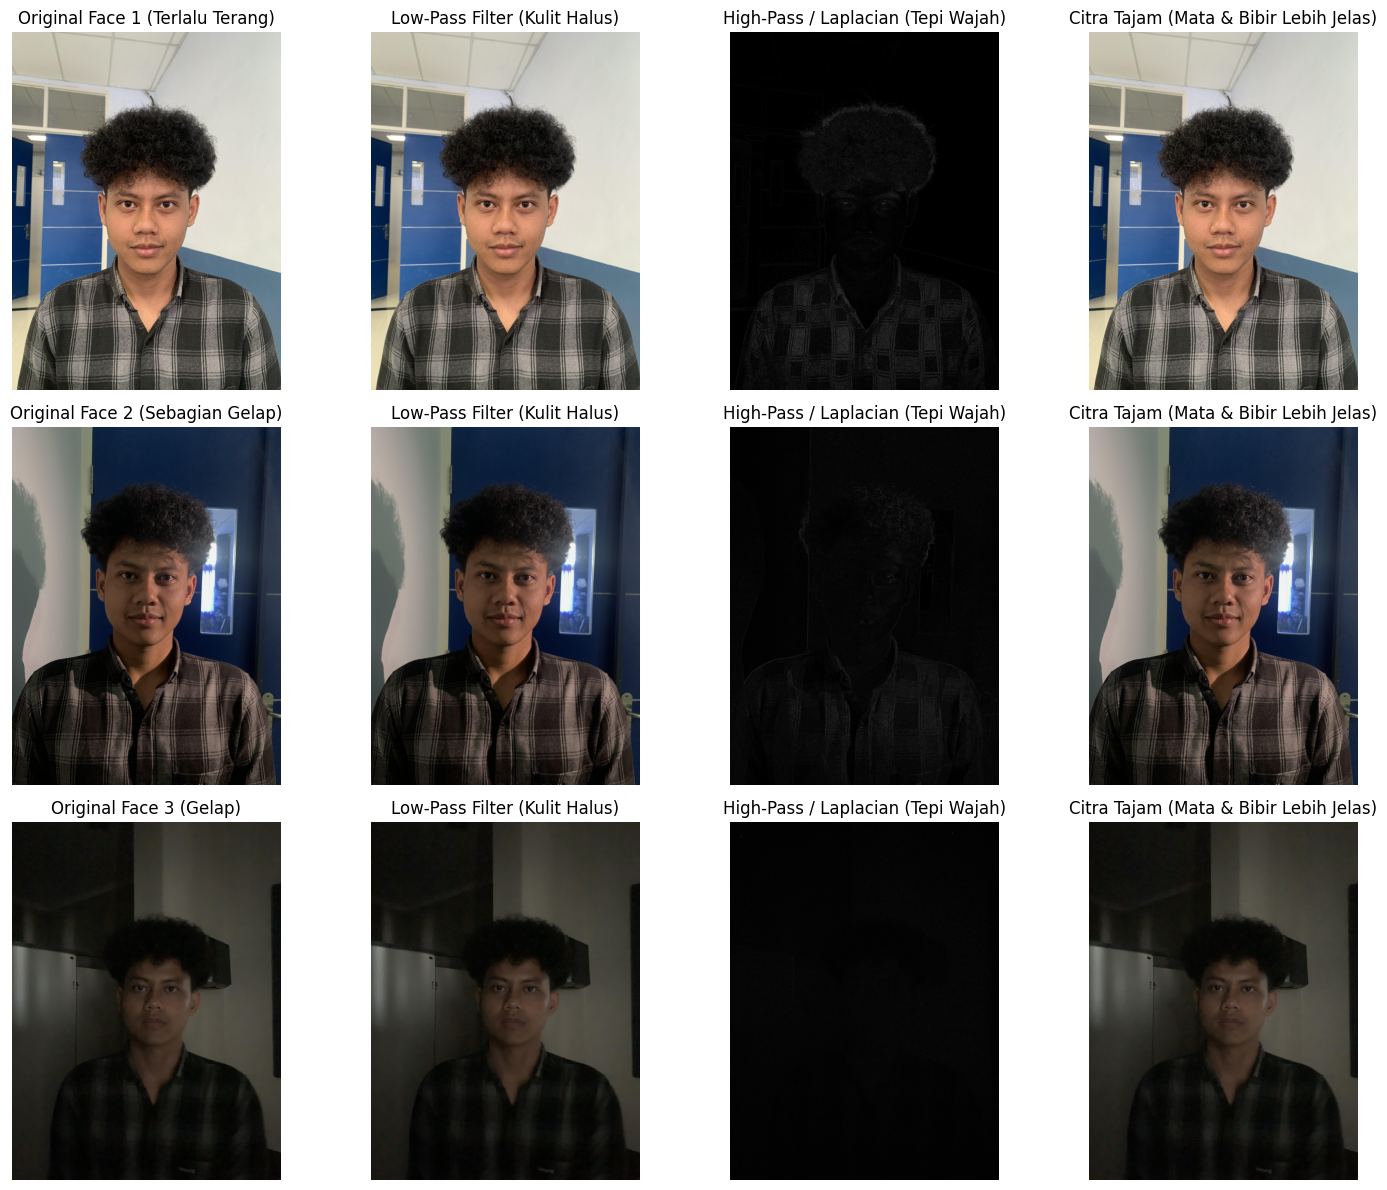

In [ ]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

# ====== Path gambar ======
path1 = '/content/drive/MyDrive/PCVK/kaconkface/face1.jpg'
path2 = '/content/drive/MyDrive/PCVK/kaconkface/face2.jpg'
path3 = '/content/drive/MyDrive/PCVK/kaconkface/face3.jpg'

# ====== Baca gambar dalam format warna (BGR) ======
face1 = cv2.imread(path1)
face2 = cv2.imread(path2)
face3 = cv2.imread(path3)

if face1 is None or face2 is None or face3 is None:
    print("⚠️ Gagal membaca gambar! Cek path file.")
else:
    print("✅ Gambar berhasil dibaca dalam format warna!")

    faces = [face1, face2, face3]
    titles = ['Face 1 (Terlalu Terang)', 'Face 2 (Sebagian Gelap)', 'Face 3 (Gelap)']

    plt.figure(figsize=(15, 12))

    for i, (img, title) in enumerate(zip(faces, titles)):
        # Konversi BGR → RGB untuk matplotlib
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # ====== 1. LOW-PASS FILTER (Gaussian Blur) ======
        low_pass = cv2.GaussianBlur(img_rgb, (9, 9), 2)  # menghaluskan kulit

        # ====== 2. HIGH-PASS FILTER (Laplacian) ======
        gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)
        laplacian = cv2.Laplacian(gray, cv2.CV_64F)
        laplacian = cv2.convertScaleAbs(laplacian)

        # Gabungkan hasil Laplacian ke citra asli (penajaman)
        laplacian_colored = cv2.cvtColor(laplacian, cv2.COLOR_GRAY2RGB)
        sharpened = cv2.addWeighted(img_rgb, 1.0, laplacian_colored, 0.5, 0)

        # ====== Tampilkan hasil ======
        plt.subplot(3, 4, 4*i + 1)
        plt.imshow(img_rgb)
        plt.title(f'Original {title}')
        plt.axis('off')

        plt.subplot(3, 4, 4*i + 2)
        plt.imshow(low_pass)
        plt.title('Low-Pass Filter (Kulit Halus)')
        plt.axis('off')

        plt.subplot(3, 4, 4*i + 3)
        plt.imshow(laplacian, cmap='gray')
        plt.title('High-Pass / Laplacian (Tepi Wajah)')
        plt.axis('off')

        plt.subplot(3, 4, 4*i + 4)
        plt.imshow(sharpened)
        plt.title('Citra Tajam (Mata & Bibir Lebih Jelas)')
        plt.axis('off')

    plt.tight_layout()
    plt.show()


✅ Gambar berhasil dibaca!


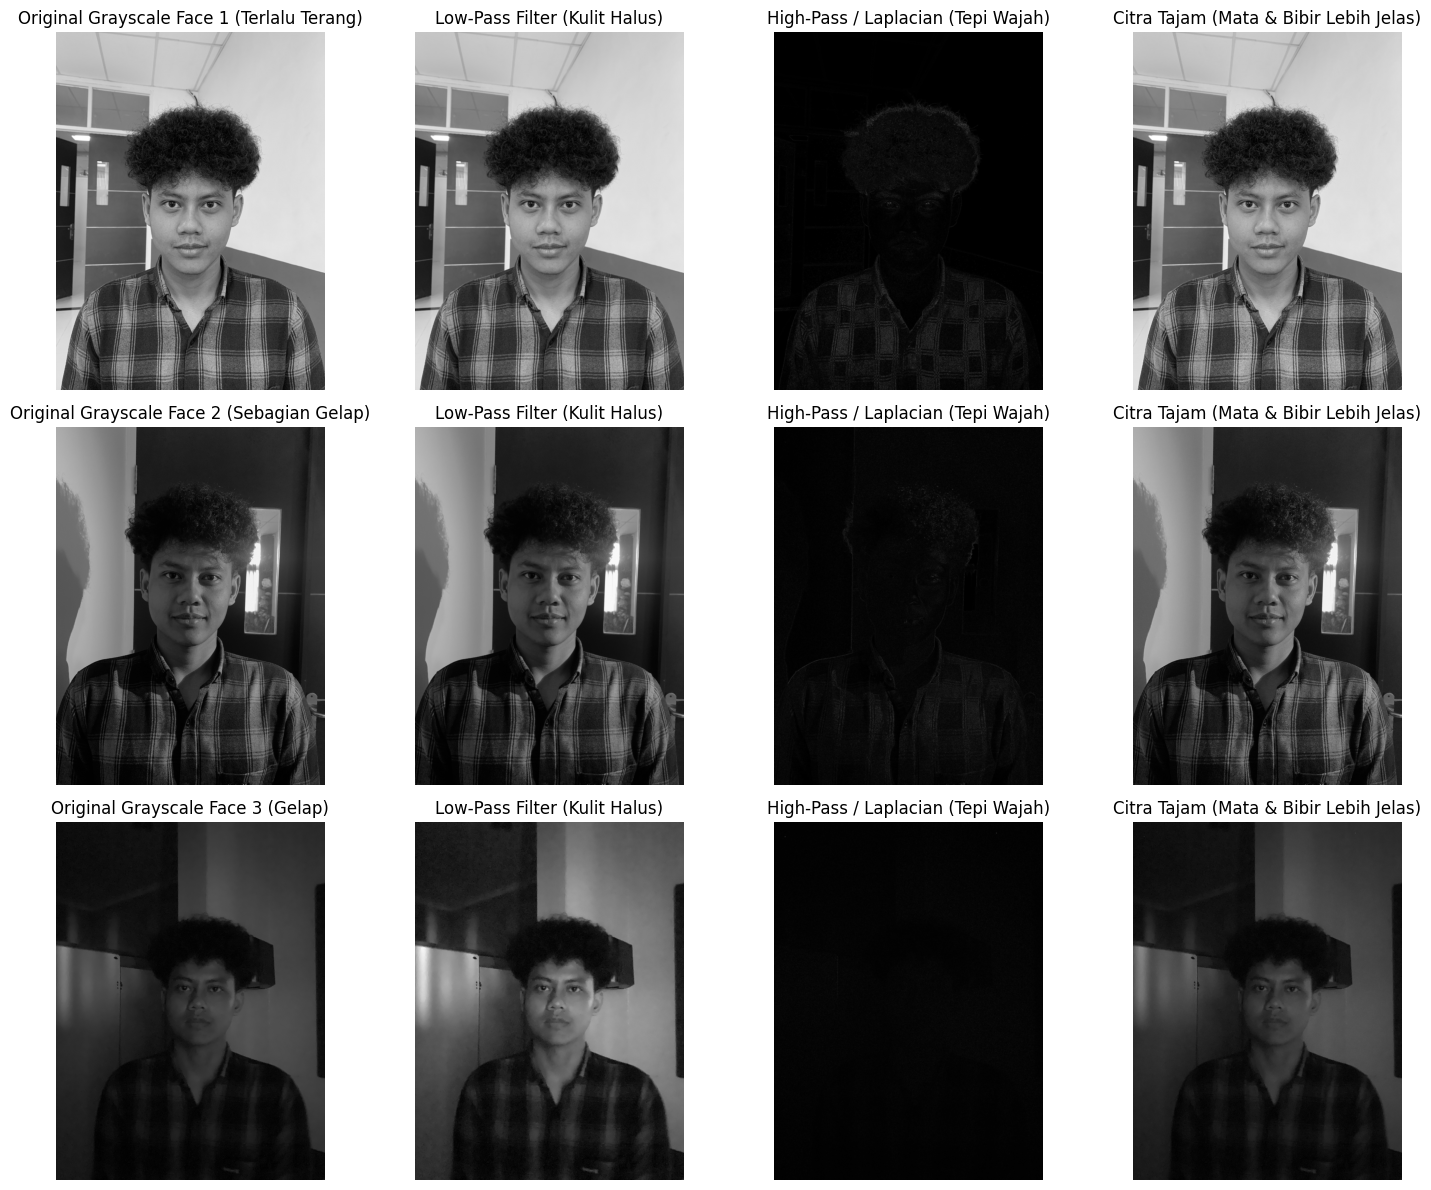

In [ ]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

# ====== Path gambar ======
path1 = '/content/drive/MyDrive/PCVK/kaconkface/face1.jpg'
path2 = '/content/drive/MyDrive/PCVK/kaconkface/face2.jpg'
path3 = '/content/drive/MyDrive/PCVK/kaconkface/face3.jpg'

# ====== Baca gambar dalam format warna (BGR) ======
face1 = cv2.imread(path1)
face2 = cv2.imread(path2)
face3 = cv2.imread(path3)

if face1 is None or face2 is None or face3 is None:
    print("⚠️ Gagal membaca gambar! Cek path file.")
else:
    print("✅ Gambar berhasil dibaca!")

    faces = [face1, face2, face3]
    titles = ['Face 1 (Terlalu Terang)', 'Face 2 (Sebagian Gelap)', 'Face 3 (Gelap)']

    plt.figure(figsize=(15, 12))

    for i, (img, title) in enumerate(zip(faces, titles)):
        # ====== Konversi ke Grayscale ======
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

        # ====== 1. LOW-PASS FILTER (Gaussian Blur) ======
        low_pass = cv2.GaussianBlur(gray, (9, 9), 2)

        # ====== 2. HIGH-PASS FILTER (Laplacian) ======
        laplacian = cv2.Laplacian(gray, cv2.CV_64F)
        laplacian = cv2.convertScaleAbs(laplacian)

        # ====== 3. Kombinasi untuk Penajaman ======
        sharpened = cv2.addWeighted(gray, 1.0, laplacian, 0.5, 0)

        # ====== Tampilkan hasil ======
        plt.subplot(3, 4, 4*i + 1)
        plt.imshow(gray, cmap='gray')
        plt.title(f'Original Grayscale {title}')
        plt.axis('off')

        plt.subplot(3, 4, 4*i + 2)
        plt.imshow(low_pass, cmap='gray')
        plt.title('Low-Pass Filter (Kulit Halus)')
        plt.axis('off')

        plt.subplot(3, 4, 4*i + 3)
        plt.imshow(laplacian, cmap='gray')
        plt.title('High-Pass / Laplacian (Tepi Wajah)')
        plt.axis('off')

        plt.subplot(3, 4, 4*i + 4)
        plt.imshow(sharpened, cmap='gray')
        plt.title('Citra Tajam (Mata & Bibir Lebih Jelas)')
        plt.axis('off')

    plt.tight_layout()
    plt.show()


5. Implementasikan Floyd–Steinberg Dithering untuk menurunkan kedalaman warna
wajah (bit-depth 4–6 bit), lalu analisis bagaimana efeknya terhadap detail dan ekspresi
wajah. **bold text**

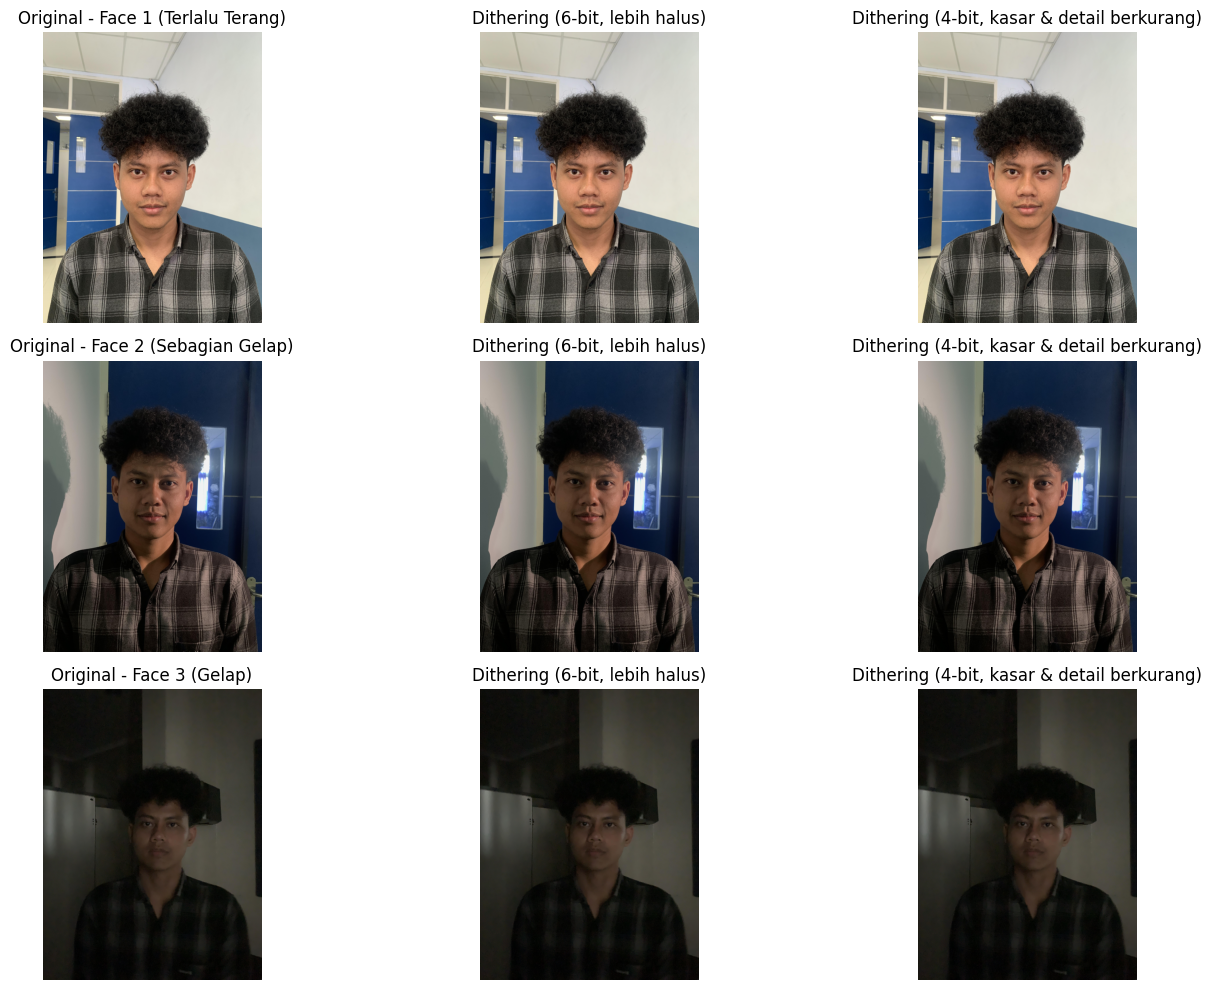

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# ====== Path gambar ======
path1 = '/content/drive/MyDrive/PCVK/kaconkface/face1.jpg'
path2 = '/content/drive/MyDrive/PCVK/kaconkface/face2.jpg'
path3 = '/content/drive/MyDrive/PCVK/kaconkface/face3.jpg'

# ====== Baca gambar RGB ======
face1 = cv2.cvtColor(cv2.imread(path1), cv2.COLOR_BGR2RGB)
face2 = cv2.cvtColor(cv2.imread(path2), cv2.COLOR_BGR2RGB)
face3 = cv2.cvtColor(cv2.imread(path3), cv2.COLOR_BGR2RGB)
faces = [face1, face2, face3]
titles = ['Face 1 (Terlalu Terang)', 'Face 2 (Sebagian Gelap)', 'Face 3 (Gelap)']

# ====== FUNGSI DITHERING OPTIMIZED ======
def floyd_steinberg_dithering_fast(image, bit_depth=4):
    """
    Floyd–Steinberg Dithering versi cepat dengan NumPy.
    Mengurangi kedalaman warna RGB tanpa loop per piksel.
    """
    img = image.astype(np.float32) / 255.0
    h, w, c = img.shape
    levels = 2 ** bit_depth
    step = 1.0 / (levels - 1)

    # Proses tiap channel RGB secara vectorized
    for y in range(h - 1):
        old_row = img[y, :, :]
        new_row = np.round(old_row / step) * step
        error_row = old_row - new_row
        img[y, :, :] = new_row

        if y + 1 < h:
            img[y, 1:, :] += error_row[:-1, :] * 7/16
            img[y + 1, :-1, :] += error_row[1:, :] * 3/16
            img[y + 1, :, :] += error_row * 5/16
            img[y + 1, 1:, :] += error_row[:-1, :] * 1/16

    return np.clip(img * 255, 0, 255).astype(np.uint8)

# ====== PROSES DAN TAMPILKAN ======
plt.figure(figsize=(15, 10))

for i, (img, title) in enumerate(zip(faces, titles)):
    dithered_6bit = floyd_steinberg_dithering_fast(img, bit_depth=6)
    dithered_4bit = floyd_steinberg_dithering_fast(img, bit_depth=4)

    plt.subplot(3, 3, 3*i + 1)
    plt.imshow(img)
    plt.title(f'Original - {title}')
    plt.axis('off')

    plt.subplot(3, 3, 3*i + 2)
    plt.imshow(dithered_6bit)
    plt.title('Dithering (6-bit, lebih halus)')
    plt.axis('off')

    plt.subplot(3, 3, 3*i + 3)
    plt.imshow(dithered_4bit)
    plt.title('Dithering (4-bit, kasar & detail berkurang)')
    plt.axis('off')

plt.tight_layout()
plt.show()


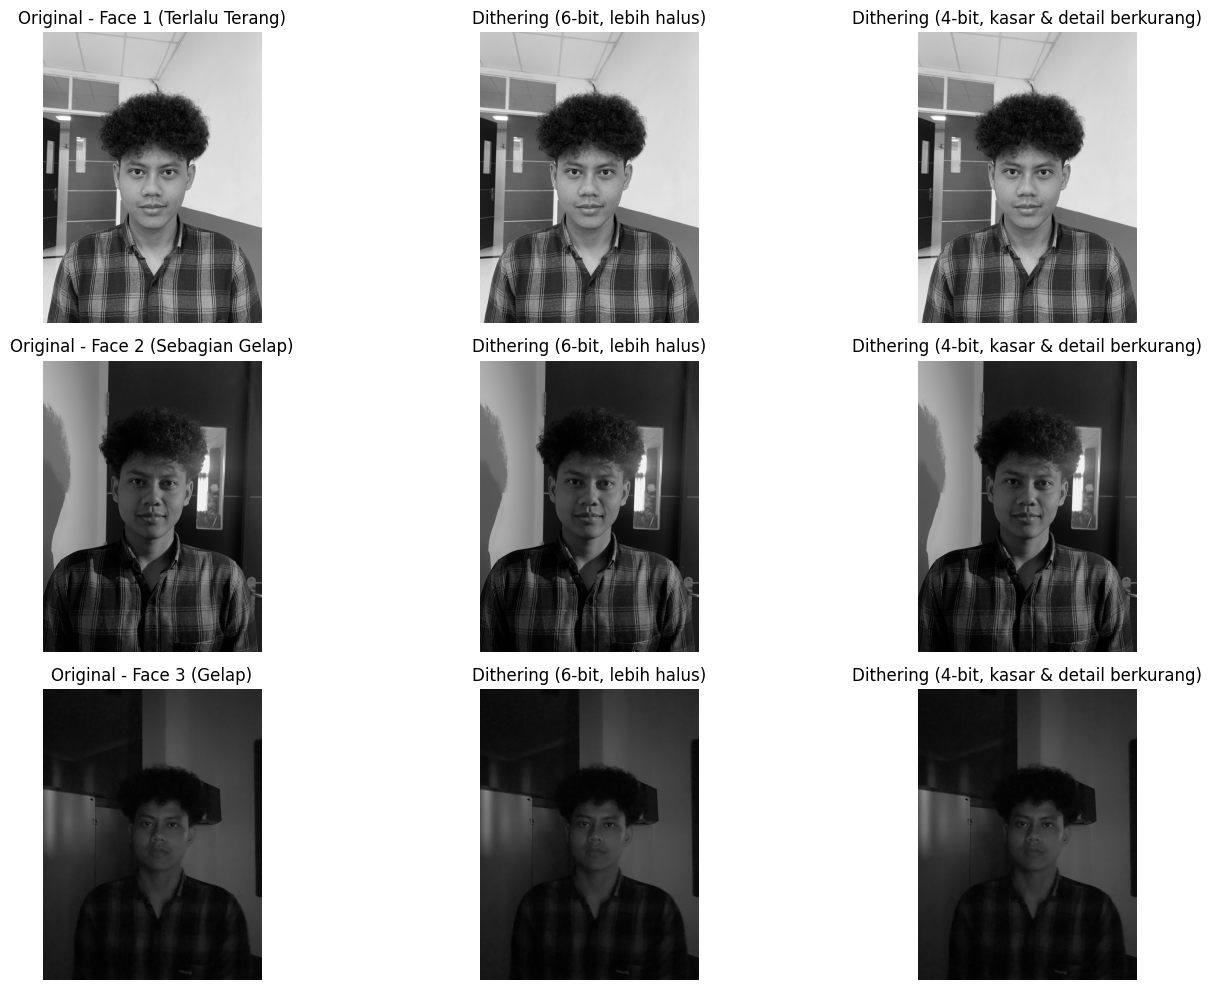

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# ====== Path gambar ======
path1 = '/content/drive/MyDrive/PCVK/kaconkface/face1.jpg'
path2 = '/content/drive/MyDrive/PCVK/kaconkface/face2.jpg'
path3 = '/content/drive/MyDrive/PCVK/kaconkface/face3.jpg'

# ====== Baca gambar dalam mode GRAYSCALE ======
face1 = cv2.imread(path1, cv2.IMREAD_GRAYSCALE)
face2 = cv2.imread(path2, cv2.IMREAD_GRAYSCALE)
face3 = cv2.imread(path3, cv2.IMREAD_GRAYSCALE)
faces = [face1, face2, face3]
titles = ['Face 1 (Terlalu Terang)', 'Face 2 (Sebagian Gelap)', 'Face 3 (Gelap)']

# ====== FUNGSI DITHERING OPTIMIZED (GRAYSCALE) ======
def floyd_steinberg_dithering_fast(image, bit_depth=4):
    """
    Floyd–Steinberg Dithering versi cepat untuk citra GRAYSCALE.
    Mengurangi kedalaman warna abu-abu tanpa loop per piksel.
    """
    img = image.astype(np.float32) / 255.0
    h, w = img.shape
    levels = 2 ** bit_depth
    step = 1.0 / (levels - 1)

    for y in range(h - 1):
        old_row = img[y, :]
        new_row = np.round(old_row / step) * step
        error_row = old_row - new_row
        img[y, :] = new_row

        if y + 1 < h:
            img[y, 1:] += error_row[:-1] * 7/16
            img[y + 1, :-1] += error_row[1:] * 3/16
            img[y + 1, :] += error_row * 5/16
            img[y + 1, 1:] += error_row[:-1] * 1/16

    return np.clip(img * 255, 0, 255).astype(np.uint8)

# ====== PROSES DAN TAMPILKAN ======
plt.figure(figsize=(15, 10))

for i, (img, title) in enumerate(zip(faces, titles)):
    dithered_6bit = floyd_steinberg_dithering_fast(img, bit_depth=6)
    dithered_4bit = floyd_steinberg_dithering_fast(img, bit_depth=4)

    plt.subplot(3, 3, 3*i + 1)
    plt.imshow(img, cmap='gray')
    plt.title(f'Original - {title}')
    plt.axis('off')

    plt.subplot(3, 3, 3*i + 2)
    plt.imshow(dithered_6bit, cmap='gray')
    plt.title('Dithering (6-bit, lebih halus)')
    plt.axis('off')

    plt.subplot(3, 3, 3*i + 3)
    plt.imshow(dithered_4bit, cmap='gray')
    plt.title('Dithering (4-bit, kasar & detail berkurang)')
    plt.axis('off')

plt.tight_layout()
plt.show()


# **Bagian B – Analisis**
Jawablah dalam bentuk narasi atau tabel analisis singkat:
1. Bagaimana perubahan nilai brightness dan contrast memengaruhi hasil histogram wajah
gelap?
2. Apakah histogram equalization selalu memperbaiki detail wajah? Jelaskan alasannya dengan
contoh hasil Anda.
3. Bandingkan hasil low-pass dan high-pass filter pada area wajah — bagian mana yang paling
terpengaruh?
4. Mengapa proses dithering bisa mempertegas atau justru mengaburkan ekspresi wajah?
5. Berdasarkan hasil percobaan Anda, kombinasi teknik mana yang paling efektif untuk
meningkatkan readability fitur wajah sebelum tahap deteksi?

| No    | Pertanyaan                                                                                                                                        | Analisis                                                                                                                                                                                                                                                                                                             |
| ----- | ------------------------------------------------------------------------------------------------------------------------------------------------- | -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **1** | **Bagaimana perubahan nilai brightness dan contrast memengaruhi hasil histogram wajah gelap?**                                                    | Pada wajah gelap, peningkatan brightness (nilai *b* positif) menggeser histogram ke kanan, membuat area wajah lebih terang. Penambahan contrast (*a* > 1) memperlebar sebaran histogram, sehingga perbedaan terang–gelap lebih jelas. Kombinasi ini membuat fitur wajah (mata, hidung, bibir) lebih mudah dikenali.  |
| **2** | **Apakah histogram equalization selalu memperbaiki detail wajah?**                                                                                | Tidak selalu. Histogram equalization dapat memperjelas area kontras rendah, tetapi kadang menimbulkan efek berlebihan (terlalu terang/gelap) pada kulit atau bayangan. Pada citra yang sudah cukup terang, hasilnya bisa tampak kasar dan kehilangan tekstur halus.                                                  |
| **3** | **Bandingkan hasil low-pass dan high-pass filter pada area wajah — bagian mana yang paling terpengaruh?**                                         | Low-pass filter (Gaussian blur) menghaluskan kulit dan mengurangi noise, tetapi detail halus seperti garis bibir dan kontur mata menjadi lebih lembut. Sebaliknya, high-pass atau Laplacian filter menonjolkan tepi dan tekstur — garis mata, bibir, dan rambut tampak lebih tajam, namun noise juga ikut meningkat. |
| **4** | **Mengapa proses dithering bisa mempertegas atau justru mengaburkan ekspresi wajah?**                                                             | Dithering menggunakan pola titik-titik untuk mensimulasikan gradasi. Pada bit-depth tinggi (6 bit), pola halus dan ekspresi wajah masih jelas. Namun pada bit-depth rendah (4 bit), gradasi berubah menjadi blok kasar sehingga ekspresi dan detail wajah bisa kabur.                                                |
| **5** | **Berdasarkan hasil percobaan Anda, kombinasi teknik mana yang paling efektif untuk meningkatkan readability fitur wajah sebelum tahap deteksi?** | Kombinasi paling efektif adalah **penyesuaian brightness & contrast** diikuti **histogram equalization ringan**, lalu **low-pass filter** untuk mengurangi noise sebelum tahap deteksi. Teknik ini menjaga detail penting sambil menstabilkan pencahayaan antar wajah.                                               |


# **Bagian C – Implementasi**

Gunakan struktur kode seperti:
import cv2, numpy as np, matplotlib.pyplot as plt
img = cv2.imread('face1.jpg', cv2.IMREAD_COLOR)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

**A.) Brightness & Contrast**

b, a = 30, 1.2
img_bc = cv2.convertScaleAbs(gray, alpha=a, beta=b)

**B.) Histogram Equalization**

img_he = cv2.equalizeHist(img_bc)

**C.) [link text](https://)Spatial Filtering (contoh High-pass)**

kernel_hp = np.array([[-1, -1, -1], [-1, 8, -1], [-1, -1, -1]])
img_hp = cv2.filter2D(img_he, -1, kernel_hp)
Kemudian tampilkan hasil 4 tahap (asli → BC → HE → Filter → Dithered).

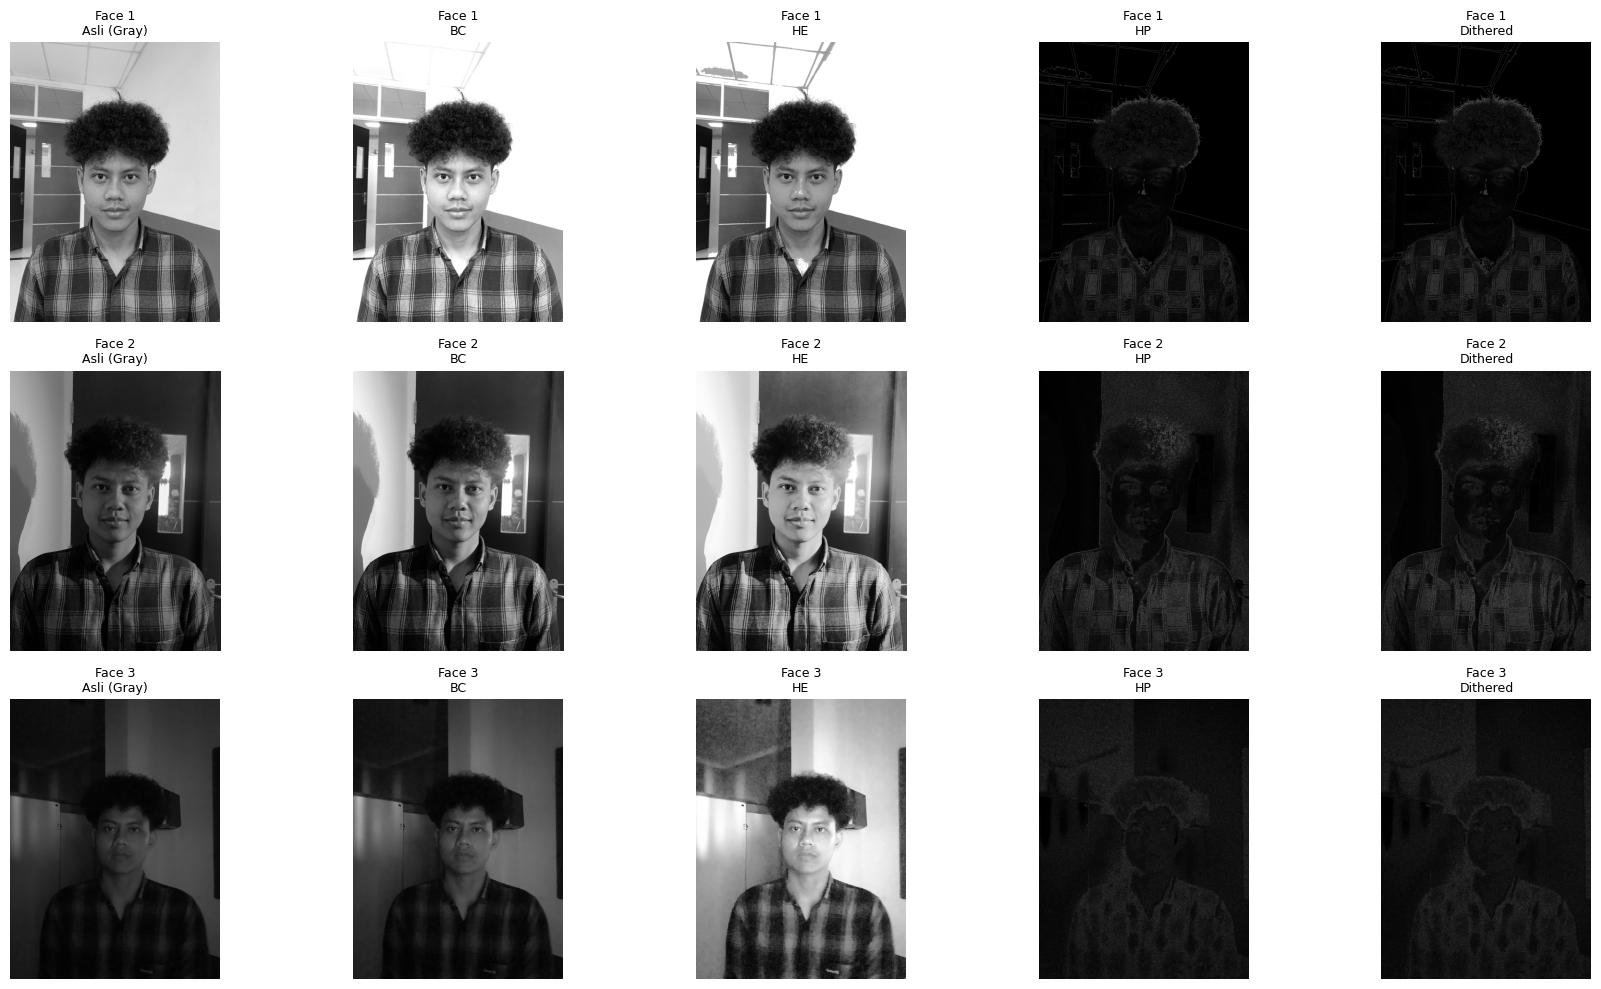

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# =========================
# => Input gambar (3 wajah)
# =========================
paths = [
    '/content/drive/MyDrive/PCVK/kaconkface/face1.jpg',
    '/content/drive/MyDrive/PCVK/kaconkface/face2.jpg',
    '/content/drive/MyDrive/PCVK/kaconkface/face3.jpg'
]

faces = []
for p in paths:
    img = cv2.imread(p, cv2.IMREAD_COLOR)
    if img is None:
        raise FileNotFoundError(f"File '{p}' tidak ditemukan. Pastikan path benar.")
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    faces.append(gray)

titles_face = ['Face 1', 'Face 2', 'Face 3']

# =========================
# => Fungsi Dithering Floyd–Steinberg (grayscale)
# =========================
def floyd_steinberg_dither_gray(image, bits=4):
    arr = image.astype(np.float32).copy()
    h, w = arr.shape
    levels = 2 ** bits
    step = 255.0 / (levels - 1)

    for y in range(h):
        for x in range(w):
            old = arr[y, x]
            new = round(old / step) * step
            arr[y, x] = new
            err = old - new
            if x + 1 < w:
                arr[y, x+1] += err * 7/16
            if y + 1 < h:
                if x - 1 >= 0:
                    arr[y+1, x-1] += err * 3/16
                arr[y+1, x] += err * 5/16
                if x + 1 < w:
                    arr[y+1, x+1] += err * 1/16
    return np.clip(arr, 0, 255).astype(np.uint8)

# =========================
# => Parameter Brightness & Contrast
# =========================
b, a = 30, 1.2
kernel_hp = np.array([[-1, -1, -1],
                      [-1,  8, -1],
                      [-1, -1, -1]])

# =========================
# => Proses dan tampilkan hasil
# =========================
plt.figure(figsize=(18, 10))

for i, (gray, face_title) in enumerate(zip(faces, titles_face)):

    # Tahap 1: Brightness & Contrast
    img_bc = cv2.convertScaleAbs(gray, alpha=a, beta=b)

    # Tahap 2: Histogram Equalization
    img_he = cv2.equalizeHist(img_bc)

    # Tahap 3: High-pass Filter
    img_hp = cv2.filter2D(img_he, -1, kernel_hp)

    # Tahap 4: Dithering
    img_dithered = floyd_steinberg_dither_gray(img_hp, bits=4)

    # Kumpulan hasil
    results = [gray, img_bc, img_he, img_hp, img_dithered]
    titles = ['Asli (Gray)', 'BC', 'HE', 'HP', 'Dithered']

    for j, (res, t) in enumerate(zip(results, titles)):
        plt.subplot(3, 5, i*5 + j + 1)
        plt.imshow(res, cmap='gray')
        plt.title(f'{face_title}\n{t}', fontsize=9)
        plt.axis('off')

plt.tight_layout()
plt.show()
